In [8]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Regression Models
from sklearn.linear_model import LinearRegression, Ridge, Lasso

# Evaluation
from sklearn.metrics import r2_score, mean_absolute_error, root_mean_squared_error

# Cross Validation
from sklearn.model_selection import cross_val_score

# Save Model
import joblib

In [9]:
df = pd.read_csv("D:/all data/folder before/insurance.csv")

df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [10]:
# Shape
df.shape

(1338, 7)

In [11]:
# Information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [12]:
# Statistics
df.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [13]:
# Missing values
df.isnull().sum()

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [14]:
# Duplicate values
df.duplicated().sum()

np.int64(1)

In [15]:
df.nunique()


age           47
sex            2
bmi          548
children       6
smoker         2
region         4
charges     1337
dtype: int64

In [16]:
df["sex"].value_counts()


sex
male      676
female    662
Name: count, dtype: int64

In [17]:
df["smoker"].value_counts()


smoker
no     1064
yes     274
Name: count, dtype: int64

In [18]:
df["region"].value_counts()


region
southeast    364
southwest    325
northwest    325
northeast    324
Name: count, dtype: int64

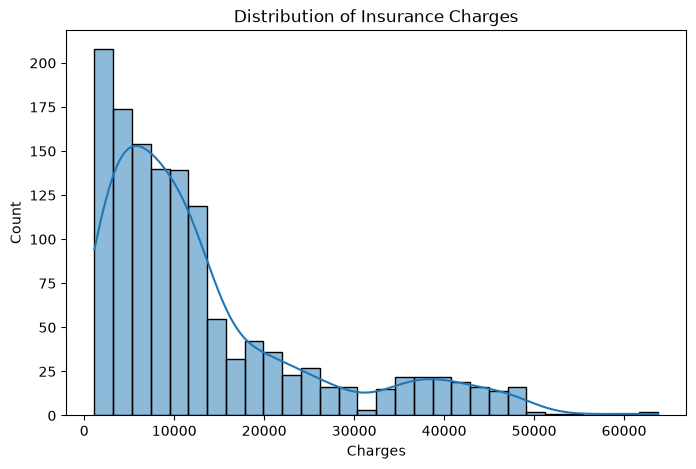

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df["charges"], bins=30, kde=True)

plt.title("Distribution of Insurance Charges")
plt.xlabel("Charges")
plt.ylabel("Count")

plt.show()

In [20]:
# The insurance charges are right-skewed. Most individuals have lower insurance costs, while a small number of customers have very high charges.

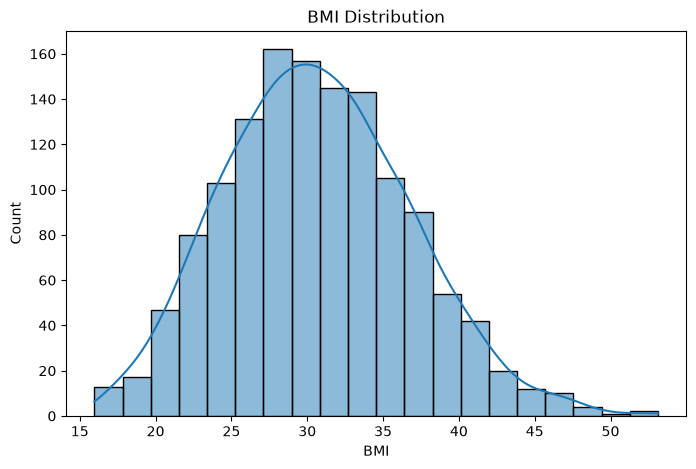

In [21]:
plt.figure(figsize=(8,5))
sns.histplot(df["bmi"], bins=20, kde=True)

plt.title("BMI Distribution")
plt.xlabel("BMI")
plt.ylabel("Count")

plt.show()

In [22]:
#BMI values are concentrated around the average range. A few individuals have higher BMI values.

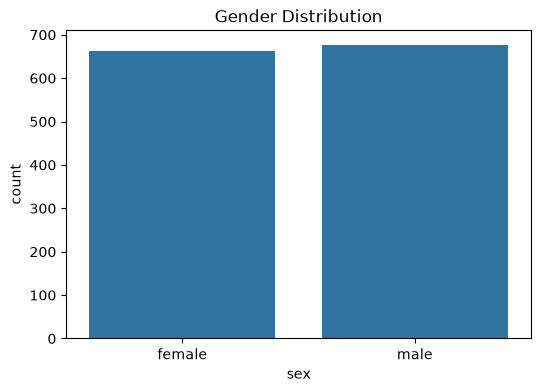

In [23]:
plt.figure(figsize=(6,4))
sns.countplot(x="sex", data=df)

plt.title("Gender Distribution")

plt.show()

In [24]:
#The dataset contains both male and female customers. The distribution is nearly balanced.

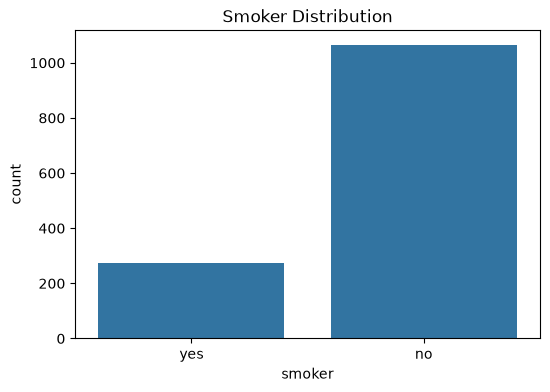

In [25]:
plt.figure(figsize=(6,4))
sns.countplot(x="smoker", data=df)

plt.title("Smoker Distribution")

plt.show()

In [26]:
#Most customers are non-smokers, while smokers represent a smaller portion of the dataset.

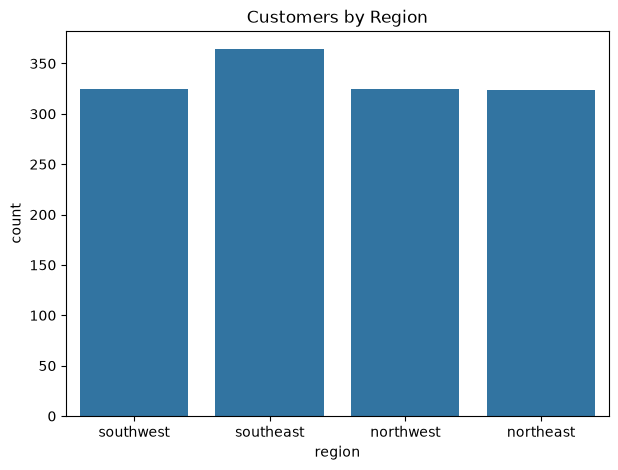

In [27]:
plt.figure(figsize=(7,5))
sns.countplot(x="region", data=df)

plt.title("Customers by Region")

plt.show()

In [28]:
#Customers belong to four different regions. The distribution across regions is fairly balanced.

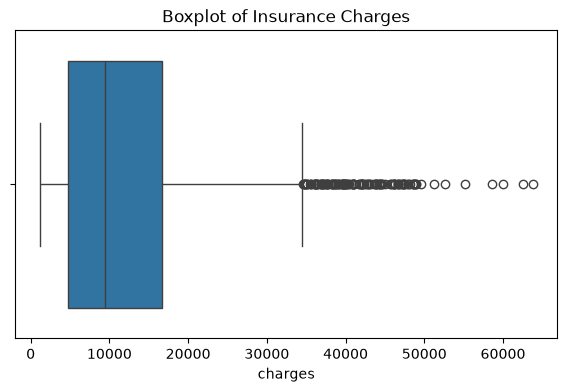

In [29]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["charges"])

plt.title("Boxplot of Insurance Charges")

plt.show()

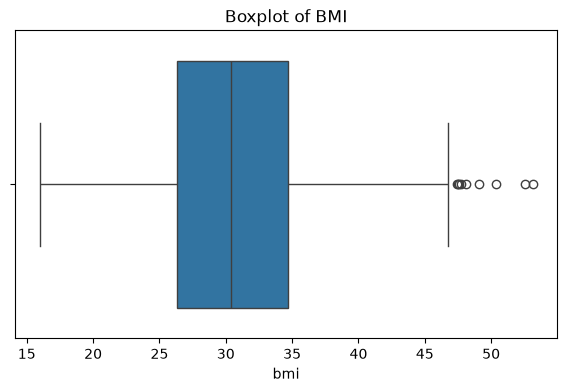

In [30]:
plt.figure(figsize=(7,4))
sns.boxplot(x=df["bmi"])

plt.title("Boxplot of BMI")

plt.show()

In [31]:
#A few extreme values are present in BMI and insurance charges. These values may influence regression model performance.

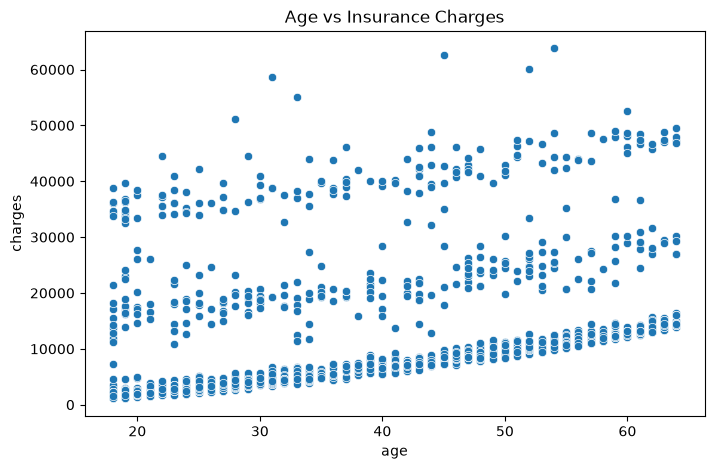

In [32]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="age", y="charges", data=df)

plt.title("Age vs Insurance Charges")

plt.show()

In [33]:
#Insurance charges generally increase with age, although some variation exists among individuals.

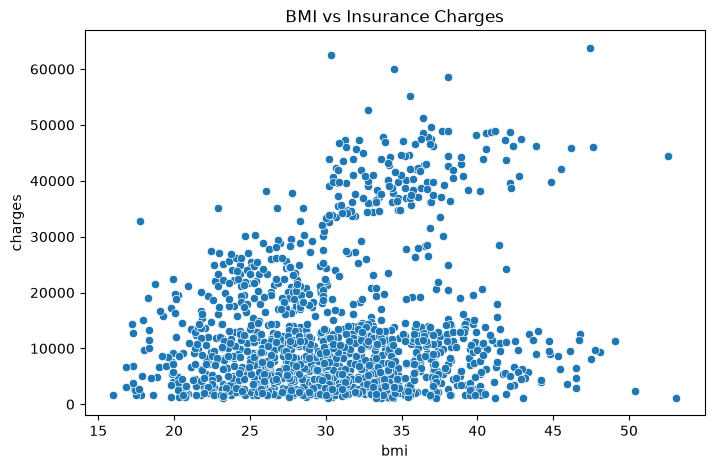

In [34]:
plt.figure(figsize=(8,5))
sns.scatterplot(x="bmi", y="charges", data=df)

plt.title("BMI vs Insurance Charges")

plt.show()

In [35]:
#Individuals with higher BMI tend to have higher insurance charges, particularly among some customers.

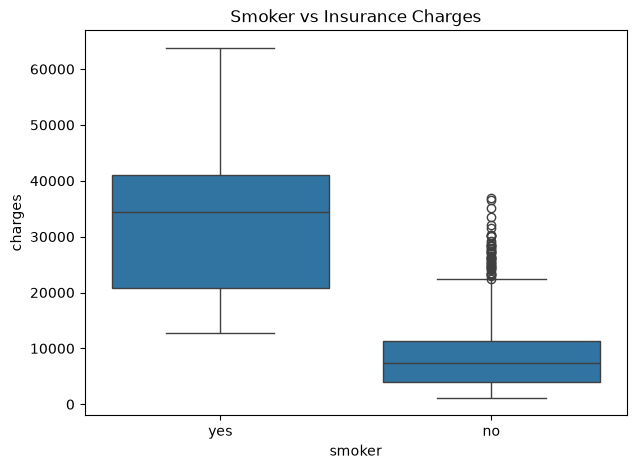

In [36]:
plt.figure(figsize=(7,5))
sns.boxplot(x="smoker", y="charges", data=df)

plt.title("Smoker vs Insurance Charges")

plt.show()

In [37]:
# Smokers generally have much higher insurance charges than non-smokers.

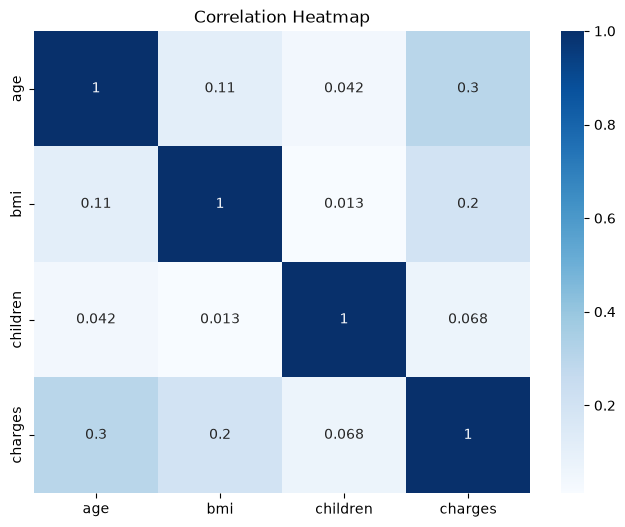

In [38]:
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="Blues"
)

plt.title("Correlation Heatmap")

plt.show()

In [39]:
# Insurance charges show a positive correlation with age and BMI. Other numerical features have weaker relationships with the target variable.

In [40]:
# Features
X = df.drop("charges", axis=1)

# Target
y = df["charges"]

In [41]:
# Numerical Columns
num_features = ["age", "bmi", "children"]

# Categorical Columns
cat_features = ["sex", "smoker", "region"]

In [42]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [43]:
num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="mean")),
    ("scaler", StandardScaler())
])

In [44]:
cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

In [45]:
preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])

In [46]:
X_train_processed = preprocessor.fit_transform(X_train)

X_test_processed = preprocessor.transform(X_test)

In [47]:
print(X_train_processed.shape)
print(X_test_processed.shape)

(1070, 11)
(268, 11)


In [48]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error


In [49]:
# Create Linear Regression model
linear_model = LinearRegression()

# Train the model
linear_model.fit(X_train_processed, y_train)

# Make predictions
linear_pred = linear_model.predict(X_test_processed)

In [50]:
linear_r2 = r2_score(y_test, linear_pred)
linear_mae = mean_absolute_error(y_test, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_test, linear_pred))

print("Linear Regression Results")
print("R² Score:", linear_r2)
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)

Linear Regression Results
R² Score: 0.7835929767120723
MAE: 4181.19447375365
RMSE: 5796.2846592762735


In [51]:
# Create Ridge Regression model
ridge_model = Ridge(alpha=1.0)

# Train the model
ridge_model.fit(X_train_processed, y_train)

# Make predictions
ridge_pred = ridge_model.predict(X_test_processed)

In [52]:
ridge_r2 = r2_score(y_test, ridge_pred)
ridge_mae = mean_absolute_error(y_test, ridge_pred)
ridge_rmse = np.sqrt(mean_squared_error(y_test, ridge_pred))

print("Ridge Regression Results")
print("R² Score:", ridge_r2)
print("MAE:", ridge_mae)
print("RMSE:", ridge_rmse)

Ridge Regression Results
R² Score: 0.7834425531348183
MAE: 4186.91307178384
RMSE: 5798.29879541548


In [53]:
# Create Lasso Regression model
lasso_model = Lasso(alpha=1.0)

# Train the model
lasso_model.fit(X_train_processed, y_train)

# Make predictions
lasso_pred = lasso_model.predict(X_test_processed)

In [54]:
lasso_r2 = r2_score(y_test, lasso_pred)
lasso_mae = mean_absolute_error(y_test, lasso_pred)
lasso_rmse = np.sqrt(mean_squared_error(y_test, lasso_pred))

print("Lasso Regression Results")
print("R² Score:", lasso_r2)
print("MAE:", lasso_mae)
print("RMSE:", lasso_rmse)

Lasso Regression Results
R² Score: 0.7835355059767686
MAE: 4182.08107647737
RMSE: 5797.054261443071


In [55]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "R2 Score": [
        linear_r2,
        ridge_r2,
        lasso_r2
    ],

    "MAE": [
        linear_mae,
        ridge_mae,
        lasso_mae
    ],

    "RMSE": [
        linear_rmse,
        ridge_rmse,
        lasso_rmse
    ]
})

results

,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.783593,4181.194474,5796.284659
1,Ridge Regression,0.783443,4186.913072,5798.298795
2,Lasso Regression,0.783536,4182.081076,5797.054261


In [56]:
results.sort_values(by="R2 Score", ascending=False)


,Model,R2 Score,MAE,RMSE
0,Linear Regression,0.783593,4181.194474,5796.284659
2,Lasso Regression,0.783536,4182.081076,5797.054261
1,Ridge Regression,0.783443,4186.913072,5798.298795


In [57]:
linear_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

In [58]:
ridge_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Ridge(alpha=1.0))
])

In [59]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(alpha=1.0))
])

In [60]:
linear_cv_scores = cross_val_score(
    linear_pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

ridge_cv_scores = cross_val_score(
    ridge_pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

lasso_cv_scores = cross_val_score(
    lasso_pipeline,
    X,
    y,
    cv=5,
    scoring="r2"
)

In [61]:
print("Linear Regression CV Score:", linear_cv_scores.mean())
print("Ridge Regression CV Score:", ridge_cv_scores.mean())
print("Lasso Regression CV Score:", lasso_cv_scores.mean())

Linear Regression CV Score: 0.746861624347374
Ridge Regression CV Score: 0.7468726733629275
Lasso Regression CV Score: 0.7468723804332598


In [62]:
cv_results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Ridge Regression",
        "Lasso Regression"
    ],

    "Average CV R2 Score": [
        linear_cv_scores.mean(),
        ridge_cv_scores.mean(),
        lasso_cv_scores.mean()
    ]
})

cv_results

,Model,Average CV R2 Score
0,Linear Regression,0.746862
1,Ridge Regression,0.746873
2,Lasso Regression,0.746872


In [63]:
cv_results.sort_values(
    by="Average CV R2 Score",
    ascending=False
)

,Model,Average CV R2 Score
1,Ridge Regression,0.746873
2,Lasso Regression,0.746872
0,Linear Regression,0.746862


In [64]:
best_model_name = results.loc[
    results["R2 Score"].idxmax(),
    "Model"
]

print("Best Model:", best_model_name)

Best Model: Linear Regression


In [65]:
best_r2_score = results["R2 Score"].max()

print("Best R² Score:", best_r2_score)

Best R² Score: 0.7835929767120723


In [66]:
joblib.dump(preprocessor, "../models/preprocessor.pkl")
joblib.dump(ridge_model, "../models/ridge_model.pkl")

print("Preprocessor and Model Saved Successfully")

Preprocessor and Model Saved Successfully


In [67]:
# Business Insights

#1. Smoking status has a major impact on medical insurance charges. Smokers generally have much higher insurance costs than non-smokers.

#2. Age also affects insurance charges. Older customers usually have higher medical expenses.

#3. Customers with a higher BMI may have higher insurance costs because of increased health risks.

#4. The Ridge Regression model achieved the highest average cross-validation R² score of 0.746873.

#5. The model can help insurance companies estimate medical insurance charges quickly and consistently.

# Conclusion

#Linear Regression, Ridge Regression, and Lasso Regression were trained and evaluated using R², MAE, RMSE, and five-fold cross-validation.

#Ridge Regression was selected as the best model because it achieved the highest average cross-validation R² score.

#The final model and preprocessor were saved using Joblib for future predictions.